<a href="https://colab.research.google.com/github/elizabethmrankin1/BME450-project/blob/main/BME450_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Breakdown of Dataset 1: Squat Form**

*Train*
- Bad Back = 948 images
- Bad Heel = 852 images
- Good Form = 1001 images

*Test*
- Bad Back = 349 images
- Bad Heel = 321 images
- Good Form = 310 images

*Data Source:* Zenodo Public Repository (Record 17558630)

*Dataset Size:* ~786 MB, consisting of 2,837 training images

*Classes:* Three-way classification: Bad back, Bad heel, and Good
___
**Preperation Step 1: Setup, Preparing Data**

Method: Automated retrieval via wget and extraction via unzip

To improve model generalization and handle noisy backgrounds, the following transformations were applied:

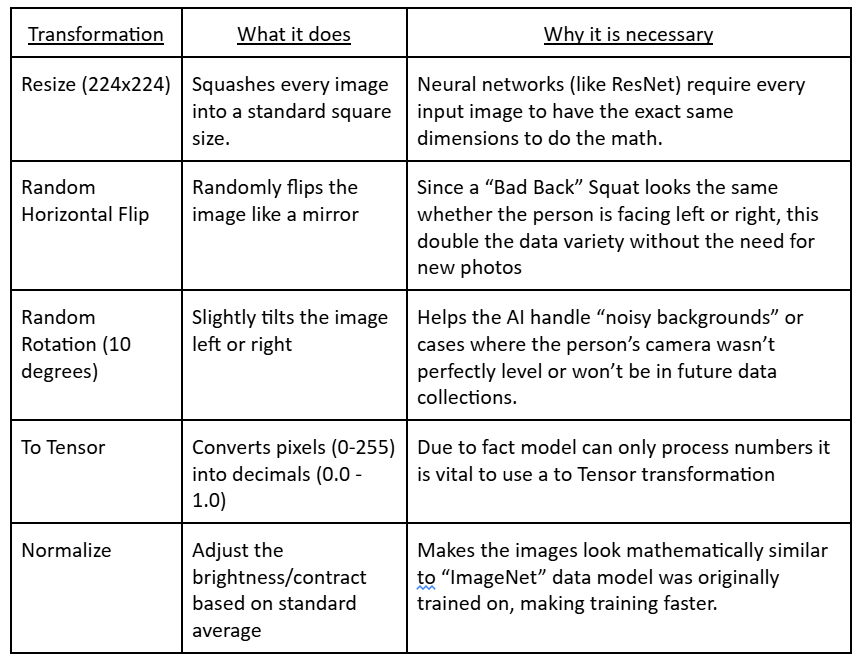


**Preperation Step 2: Model Definition and Initialization**

**Architecture Used:** Transfer Learning using ResNet-18 (Residual Network)

**Why ResNet18?** ResNet-18 has been pre-trained on the ImageNet dataset (over 1 million images). Meaning this modal already has an understanding of low-level features such as edges, textures, and human silhouette. This is critical when using a dataset like ours as we need to differentiate the person from a noisy background.

**Modification to ResNet-18 made:** Original ResNet-18 is equipt for 1,000 different object catagories. Given the dataset we are using has 3 catagories, we replaced this final layer with nn.Linear(num_features, 3).

**Measuring Performance:**
Cross-Entropy Loss, compares the predicted class to the actual labels (folder name). When model is incorrect, gives a numerical penalty to adjust its internal weights to become more accurate.

**Optimization Strategy:** Adaptive Moment Estimation (Adam), updates the model weight based on calculated loss. Adam maintains a seperate learning rate for each parameter and adjust it as training progresses.

**Hyperparameter Selection:** Learning rate ($\alpha$): Set to 0.001, standard starting point. Can be adjusted later.





In [1]:
# =================================================================
# BME 450 Final Project: Squat Form Correction
# This script handles data downloading, preprocessing, and
# baseline model setup for the Bad Back, Bad Heel, and Good classes.
# =================================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import os

# STEP 1: DOWNLOAD AND UNZIP DATA
# We use the direct link provided. -O renames it for simplicity.
print("Starting data download...")
!wget "https://zenodo.org/records/17558630/files/Dataset.zip?download=1" -O Dataset.zip

# -q (quiet) hides the 2,800+ file lines. -d specifies the directory.
print("Unzipping files...")
!unzip -q Dataset.zip -d ./squat_data

# STEP 2: DATA PREPROCESSING & AUGMENTATION
# Transforms allow the data to be processed by the neural network
# and optimize training with noisy images
# train transforms introduce randomness and test transforms only prepare data for processing
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),      # Resize images so that the neural network can process
        transforms.RandomHorizontalFlip(), # Squats look same from left or right
        transforms.RandomRotation(10),     # Account for camera tilt
        transforms.ToTensor(),             # Convert images to tensors
        # Normalization values standard for models pre-trained on ImageNet
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# STEP 3: LOAD DATA INTO PYTORCH
data_dir = './squat_data'

# ImageFolder automatically uses subfolder names as labels (0, 1, 2)
image_datasets = {
    'train': datasets.ImageFolder(os.path.join(data_dir, 'train'), data_transforms['train']),
    'test': datasets.ImageFolder(os.path.join(data_dir, 'test'), data_transforms['test'])
}

# DataLoaders handle feeding images in batches
dataloaders = {
    'train': torch.utils.data.DataLoader(image_datasets['train'], batch_size=32, shuffle=True),
    'test': torch.utils.data.DataLoader(image_datasets['test'], batch_size=32, shuffle=False)
}

# Verify the classes found
class_names = image_datasets['train'].classes
print(f"Detected Classes: {class_names}")
print(f"Total training images: {len(image_datasets['train'])}")

# STEP 4: DEFINE ARCHITECTURE
model = models.resnet18(pretrained=True)

# Change output layer to match 3 categories
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 3) # Input features from ResNet converted to 3 categories

# Send the model to the GPU (efficiency)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# STEP 5: DEFINE LOSS AND OPTIMIZER
# loss function = cross entropy loss
criterion = nn.CrossEntropyLoss() #used for categorization

# Experiment with learning rate
# note: optimizer is Adam: one of the best optimizers to date
# it can infer learning rate and all hyper-parameters automatically
optimizer = optim.Adam(model.parameters(), lr=0.001) #optimizer function
import os
# This will show us exactly what is inside the 'squat_data' folder
print("Folders found inside squat_data:")
print(os.listdir('./squat_data'))
print("Model setup complete. Ready for training!")

Starting data download...
--2026-04-25 15:35:23--  https://zenodo.org/records/17558630/files/Dataset.zip?download=1
Resolving zenodo.org (zenodo.org)... 137.138.52.235, 188.185.43.153, 188.184.98.114, ...
Connecting to zenodo.org (zenodo.org)|137.138.52.235|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824064094 (786M) [application/octet-stream]
Saving to: ‘Dataset.zip’

Dataset.zip         100%[===================>] 785.89M  1009KB/s    in 12m 42s 

2026-04-25 15:48:05 (1.03 MB/s) - ‘Dataset.zip’ saved [824064094/824064094]

Unzipping files...
Detected Classes: ['Bad back', 'Bad heel', 'Good']
Total training images: 2837


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 131MB/s]


Folders found inside squat_data:
['test', 'train']
Model setup complete. Ready for training!


**Training Step 1: The Optimization Loop (Training Execution)**

**Process Overview:** This section implements the iterative learning process where the model actually "studies" the squat dataset. We use a Mini-Batch Gradient Descent approach to update the model weights.

**Key Components of the Loop:**

**Training Mode (model.train()):** Explicitly sets the network to "Training Mode." This is vital because it activates specific behaviors (like Dropout or Batch Normalization) that are necessary for the model to learn and generalize, rather than just memorizing images.

**Batch Processing:** The dataset is divided into batches of 32 images. This ensures the GPU memory is used efficiently and provides more frequent updates to the model weights than showing all 2,837 images at once.

**The Gradient Reset (zero_grad):**
Before processing a new batch, we clear the previous mathematical gradients. This prevents the "lessons" from the last batch from bleeding into the current one, ensuring each step is based only on the current images.

**Forward Pass:** The images are passed through the ResNet-18 architecture.The model makes a prediction for each image (Good, Bad Back, or Bad Heel).

**Backpropagation (loss.backward()):** The model calculates the difference between its guess and the actual label (Loss). It then works backward from the output layer to the input layers to determine exactly which internal connections need to be strengthened or weakened.

**Weight Update (optimizer.step()):** The Adam Optimizer uses the information from backpropagation to adjust the internal weights of the model by a tiny increment (defined by the 0.001 learning rate).

**Objective:** By the end of this step, the model should show a decreasing Loss Value, indicating that it is successfully learning to distinguish between the three squat forms despite the noisy backgrounds.

**Future Direction:** In future iterations, the batch size (currently 32) and learning rate (currently 0.001) will be varied to observe impact.

**Training Step 1: Analysis of Results**

  - Initial Loss = 1.4829 - model's initial state where it has no specific knowledge of squat form and is essicially guessing
  - Rapid Convergence = 0.0386 - steep droop in losses recomends that the model is able to identify the different catagories.
  - Efficiency - model reached very low error rate

  Note! Model may be Overfitting (memorizing the training photos)

In [1]:
print ("Start training session...")

train_losses = []
test_losses = []
test_accuracies = []

for epoch in range(10):
  model.train()

  running_train_loss = 0.0
  for batch_idx, (inputs,labels) in enumerate(dataloaders['train']):
    inputs,labels = inputs.to(device), labels.to(device)
    optimizer.zero_grad()

    outputs = model(inputs)
    loss = criterion(outputs,labels)
    running_train_loss += loss.item() * inputs.size(0)

    loss.backward()

    optimizer.step()
    if batch_idx % 20 == 0:
      print(f"Batch {batch_idx}/{len(dataloaders['train'])} complete. Loss: {loss.item():.4f}")

  print(f"Epoch {epoch+1}/{10} complete.")
  epoch_train_loss = running_train_loss / len(dataloaders['train'].dataset)
  train_losses.append(epoch_train_loss)


# ---- TESTING BLOCK ----
  model.eval()  # switch to evaluation mode

  test_loss = 0.0
  correct = 0

  with torch.no_grad():  # no gradients needed for testing
     for inputs, labels in dataloaders['test']:
          inputs, labels = inputs.to(device), labels.to(device)

          outputs = model(inputs)
          loss = criterion(outputs, labels)

          test_loss += loss.item() * inputs.size(0)

          preds = torch.argmax(outputs, 1)
          correct += (preds == labels).sum().item()

  # Average loss
  test_loss = test_loss / len(dataloaders['test'].dataset)
  accuracy = correct / len(dataloaders['test'].dataset)

  print(f"Test Loss: {test_loss:.4f}")
  print(f"Test Accuracy: {accuracy*100:.2f}%")

import matplotlib.pyplot as plt

# ---- LOSS PLOT ----
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Test Loss")
plt.legend()
plt.show()

# ---- ACCURACY PLOT ----
plt.figure()
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Test Accuracy over Epochs")
plt.legend()
plt.show()

Start training session...


NameError: name 'model' is not defined